In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [48]:
plt.style.use('seaborn-v0_8-whitegrid')

In [49]:
plt.rcParams.update({
    'figure.figsize' :(13,6),
    'font.family' :'DejaVu Sans',
    'font.size'   :11,
    'axes.titlesize'  :14,
    'axes.titleweight' :'bold',
    'axes.labelsize' :11,
    'xtick.labelsize' :10,
    'ytick.labelsize': 10,
    'legend.fontsize' :10,
    'figure.dpi'  :120,
})

In [50]:
BLUE_PALETTE  = ['#1F4E79','#2E75B6','#4A90D9','#74B3CE','#A8D5F0']
MAIN_BLUE     = '#1F4E79'
ACCENT_ORANGE = '#E07B39'
SUCCESS_GREEN = '#27AE60'
DANGER_RED    = '#C0392B'

In [51]:
df = pd.read_csv("Superstore_cleaned.csv",encoding='latin-1')

In [52]:
print(df.shape)

(9977, 14)


In [53]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9977 entries, 0 to 9976
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Ship Mode      9977 non-null   object 
 1   Segment        9977 non-null   object 
 2   Country        9977 non-null   object 
 3   City           9977 non-null   object 
 4   State          9977 non-null   object 
 5   Postal Code    9977 non-null   int64  
 6   Region         9977 non-null   object 
 7   Category       9977 non-null   object 
 8   Sub-Category   9977 non-null   object 
 9   Sales          9977 non-null   float64
 10  Quantity       9977 non-null   int64  
 11  Discount       9977 non-null   float64
 12  Profit         9977 non-null   float64
 13  Profit_Margin  9977 non-null   float64
dtypes: float64(4), int64(2), object(8)
memory usage: 1.1+ MB
None


In [54]:
print(df.describe())

        Postal Code         Sales     Quantity     Discount      Profit  \
count   9977.000000   9977.000000  9977.000000  9977.000000  9977.00000   
mean   55154.964117    230.148902     3.790719     0.156278    28.69013   
std    32058.266816    623.721409     2.226657     0.206455   234.45784   
min     1040.000000      0.444000     1.000000     0.000000 -6599.97800   
25%    23223.000000     17.300000     2.000000     0.000000     1.72620   
50%    55901.000000     54.816000     3.000000     0.200000     8.67100   
75%    90008.000000    209.970000     5.000000     0.200000    29.37200   
max    99301.000000  22638.480000    14.000000     0.800000  8399.97600   

       Profit_Margin  
count    9977.000000  
mean       12.011351  
std        46.663770  
min      -275.000000  
25%         7.500000  
50%        27.000000  
75%        36.250000  
max        50.000000  


In [55]:
df['Postal Code']= df['Postal Code'].astype(str)

In [56]:
print(df.describe())

              Sales     Quantity     Discount      Profit  Profit_Margin
count   9977.000000  9977.000000  9977.000000  9977.00000    9977.000000
mean     230.148902     3.790719     0.156278    28.69013      12.011351
std      623.721409     2.226657     0.206455   234.45784      46.663770
min        0.444000     1.000000     0.000000 -6599.97800    -275.000000
25%       17.300000     2.000000     0.000000     1.72620       7.500000
50%       54.816000     3.000000     0.200000     8.67100      27.000000
75%      209.970000     5.000000     0.200000    29.37200      36.250000
max    22638.480000    14.000000     0.800000  8399.97600      50.000000


In [57]:
print(df.columns)

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Profit_Margin'],
      dtype='object')


In [58]:
#check missing value
print(df.isnull().sum())

Ship Mode        0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Category         0
Sub-Category     0
Sales            0
Quantity         0
Discount         0
Profit           0
Profit_Margin    0
dtype: int64


In [59]:
#Check duplicate value
print(df.duplicated().sum())

0


In [60]:
# Total Sales, Total Profit , Total Quantity
print(f'Total_Sales: {df['Sales'].sum().round(2)}')
print(f'Total_Profit: {df['Profit'].sum().round(2)}')
print(f'Total_Quantity: {df['Quantity'].sum()}')

Total_Sales: 2296195.59
Total_Profit: 286241.42
Total_Quantity: 37820


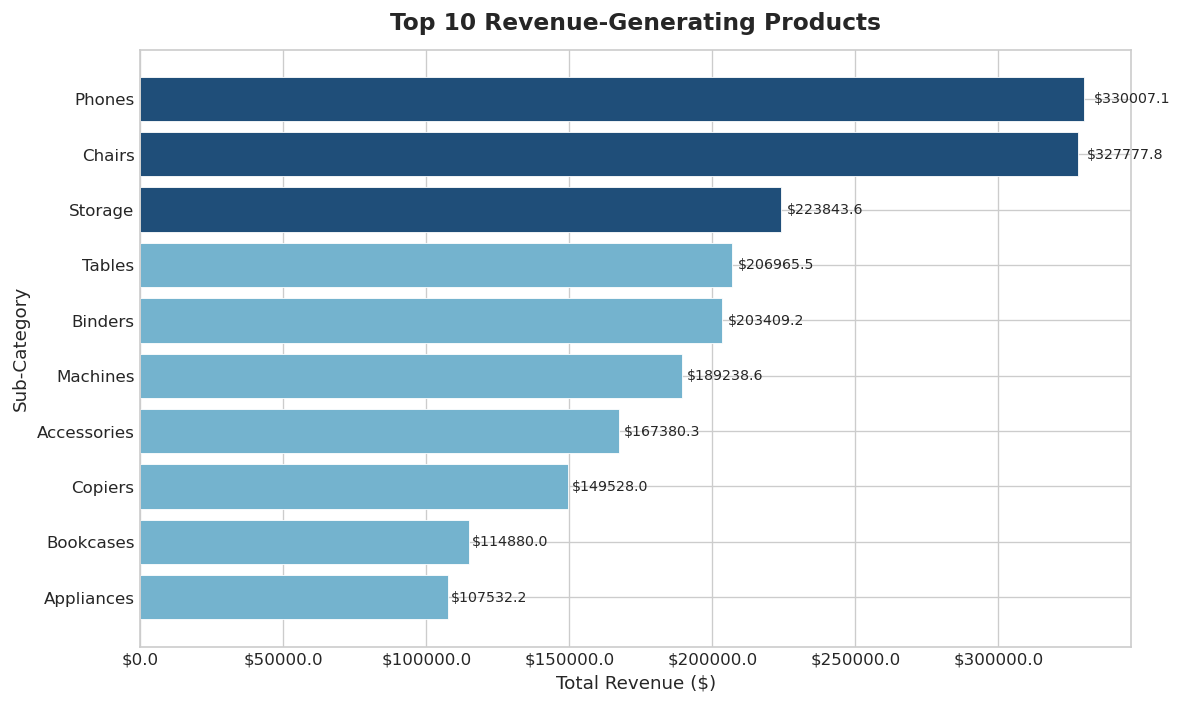

In [87]:
#. Top 10 Revenue-Generating Products
Top_Products = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending =False).head(10)
plt.figure(figsize=(10,6))
color_rev =[MAIN_BLUE if i <3 else'#74B3CE' for i in range(len(Top_Products))]
bars = plt.barh(Top_Products.index,Top_Products.values,color=color_rev,edgecolor='white',linewidth=0.5)
plt.title('Top 10 Revenue-Generating Products', pad=12)
plt.xlabel('Total Revenue ($)')
plt.ylabel('Sub-Category')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p : f'${x:.1f}'))
for bar in bars:
    w= bar.get_width()
    plt.text(w * 1.01,bar.get_y()+ bar.get_height()/2,f'${w:.1f}', va='center', fontsize=8.5)
plt.tight_layout()
plt.show()


The bar chart shows that Phones generated the highest revenue among all sub-categories, followed closely by Chairs and Storage. This indicates strong customer demand for technology products and office furniture. Products such as Machines, Accessories, and Copiers also contribute significantly to revenue, while Bookcases and Appliances generate comparatively lower revenue among the top 10 products.

The revenue distribution suggests that the business heavily depends on a few high-performing sub-categories for overall sales growth. Technology-related products dominate the revenue contribution, indicating that customers are willing to spend more on premium electronic products.

Category
Technology         836154.0330
Furniture          741306.3133
Office Supplies    718735.2440
Name: Sales, dtype: float64


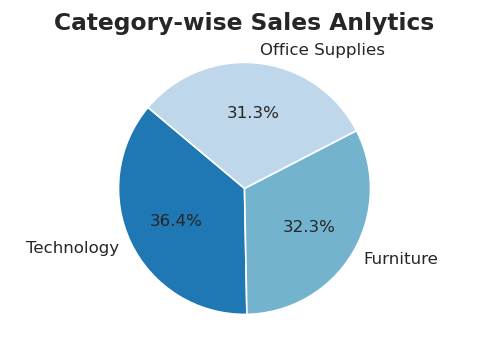

In [70]:
#Category-wise Sales Analysis
Category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(Category_sales)
colors = ['#1f77b4', '#74B3CE', '#BFD7EA']
plt.figure(figsize= (5,3))
wedges, texts, autotexts= plt.pie(Category_sales, labels = Category_sales.index,colors=colors,autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor':'white', 'linewidth':1},
    textprops={'fontsize':10}
)

plt.title('Category-wise Sales Anlytics', fontsize='14', pad =12)
plt.axis('equal')
plt.show()
           


The pie chart indicates that the Technology category contributes the highest percentage of total sales, accounting for approximately 36.4% of overall revenue. Furniture contributes around 32.3%, while Office Supplies contributes approximately 31.3%.

This shows that Technology products are the primary revenue drivers for the business. Furniture and Office Supplies also contribute significantly, indicating a balanced product portfolio across categories.


Region
West       108329.8079
East        91506.3092
South       46749.4303
Central     39655.8752
Name: Profit, dtype: float64


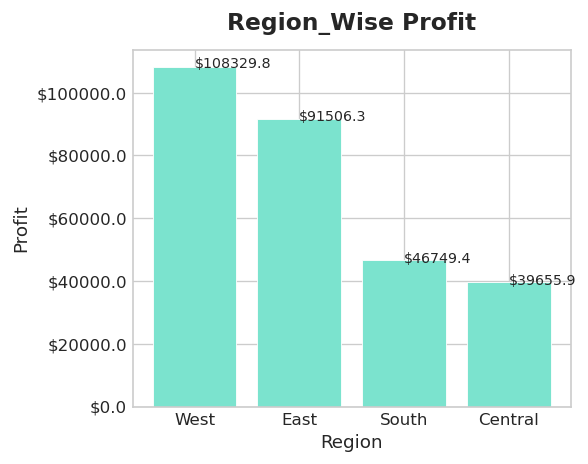

In [88]:
# Region-wise Profit Analysis
Region_Profit = df.groupby('Region')['Profit'].sum().sort_values(ascending = False)
print(Region_Profit)
plt.figure(figsize=(5,4))
bars = plt.bar(Region_Profit.index, Region_Profit.values,color='#7BE3CE',edgecolor='white',linewidth=0.5)
plt.title('Region_Wise Profit', pad=12)
plt.xlabel('Region')
plt.ylabel('Profit')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p : f'${x:.1f}'))
for bar in bars:
    w= bar.get_height()
    plt.text(bar.get_x()+ bar.get_width()/2, w*1.01,f'${w:.1f}', va='center', fontsize=8.5)
plt.tight_layout()
plt.show()





The regional profit chart shows that the West region generates the highest profit, followed closely by the East region. In contrast, the South and Central regions contribute comparatively lower profit.

The higher profitability in West and East regions may be due to:stronger customer demand,higher purchasing power,better sales performance,optimized operational efficiency.
The lower profit in South and Central regions may indicate:excessive discounting,lower sales volume,higher operational costs.

In [78]:
#Correlation Analysis
df[['Sales','Profit','Quantity','Discount']].corr()

,Sales,Profit,Quantity,Discount
Sales,1.000000,0.479067,0.200722,-0.028311
Profit,0.479067,1.000000,0.066211,-0.219662
Quantity,0.200722,0.066211,1.000000,0.008678
Discount,-0.028311,-0.219662,0.008678,1.000000


State
California      457576.2715
New York        310827.1510
Texas           170124.5418
Washington      138560.8100
Pennsylvania    116496.3620
Florida          89473.7080
Illinois         80162.5370
Ohio             77976.7640
Michigan         75879.6440
Virginia         70636.7200
Name: Sales, dtype: float64


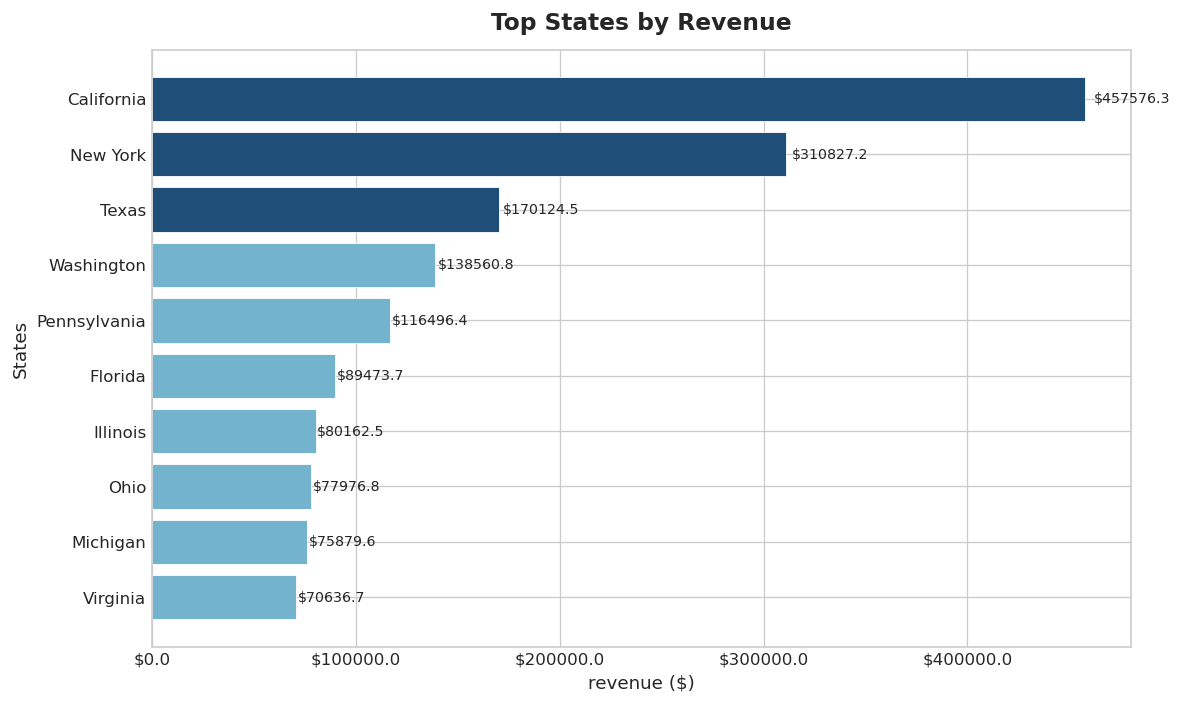

In [89]:
#12. Top States by Revenue
States_Revenue = df.groupby('State')['Sales'].sum().sort_values(ascending = False).head(10)
print(States_Revenue)
plt.figure(figsize=(10,6))
colors= [MAIN_BLUE if i < 3  else'#74B3CE'   for i in range(len(States_Revenue))]
bars = plt.barh(States_Revenue.index, States_Revenue.values, color= colors, edgecolor='white',linewidth=0.5)
plt.title('Top States by Revenue', pad =12)
plt.xlabel('revenue ($)')
plt.ylabel('States')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:.1f}'))
for bar in bars:
    w= bar.get_width()
    plt.text(w*1.01, bar.get_y()+bar.get_height()/2, f'${w:.1f}', va= 'center',fontsize=8.5)
plt.tight_layout()
plt.show()

The bar chart highlights the top-performing states based on total sales revenue. California generates the highest revenue by a significant margin, followed by New York and Texas. These states act as the primary revenue drivers for the business.The strong performance of California may be due to:
larger customer base, higher purchasing power,strong ecommerce adoption

In [91]:
#Average Profit Margin
df['profit_Margin'] = (df['Profit']/df['Sales'])*100
print(df['profit_Margin'].mean())

12.011353821539306


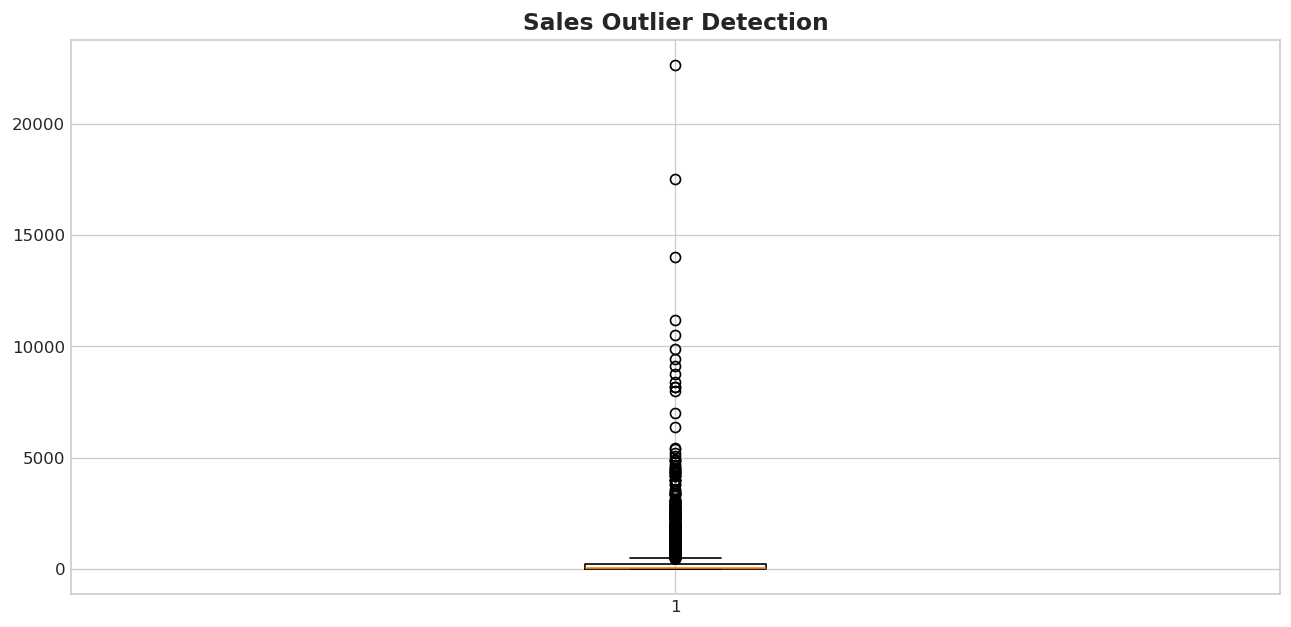

In [92]:
#Outlier Detection Using Boxplot
plt.boxplot(df['Sales'])
plt.title('Sales Outlier Detection')
plt.show()

The boxplot visualization reveals the presence of multiple sales outliers in the dataset. Most sales transactions are concentrated within a lower sales range, while a small number of orders generate exceptionally high sales values.
The long upper tail and multiple points above the upper whisker indicate:
highly skewed sales distribution
existence of large-value transactions
potential premium or bulk orders

This suggests that while the majority of customers make moderate purchases, a smaller segment contributes disproportionately high revenue.

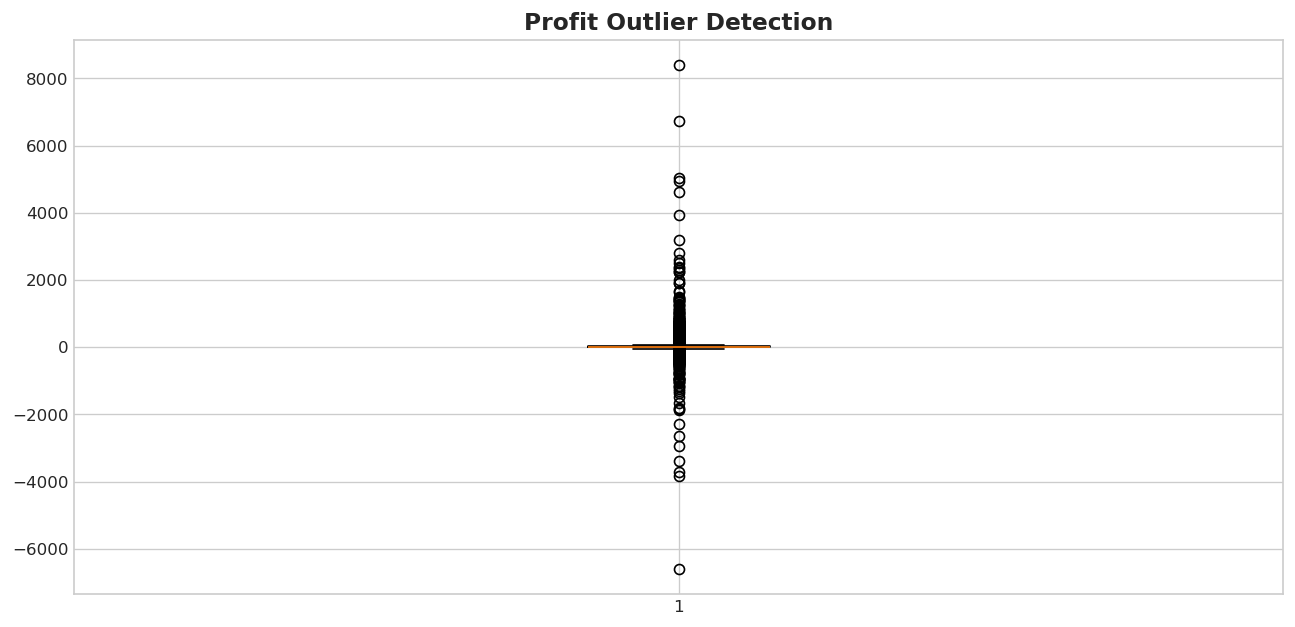

In [114]:
#Outlier Detection Using Boxplot profit
plt.boxplot(df['Profit'])
plt.title('Profit Outlier Detection')
plt.show()

The boxplot visualization reveals the presence of multiple outliers in the profit data. Most transactions are concentrated within a lower profit range, while a small number of transactions have extremely high profit values. These points above the upper whisker represent unusually large orders or premium purchases.

The presence of many upper outliers indicates that the profit distribution is highly right-skewed, meaning a limited number of transactions contribute disproportionately to overall revenue.

The chart also shows a few lower extreme values, which may represent very small purchases or discounted transactions.

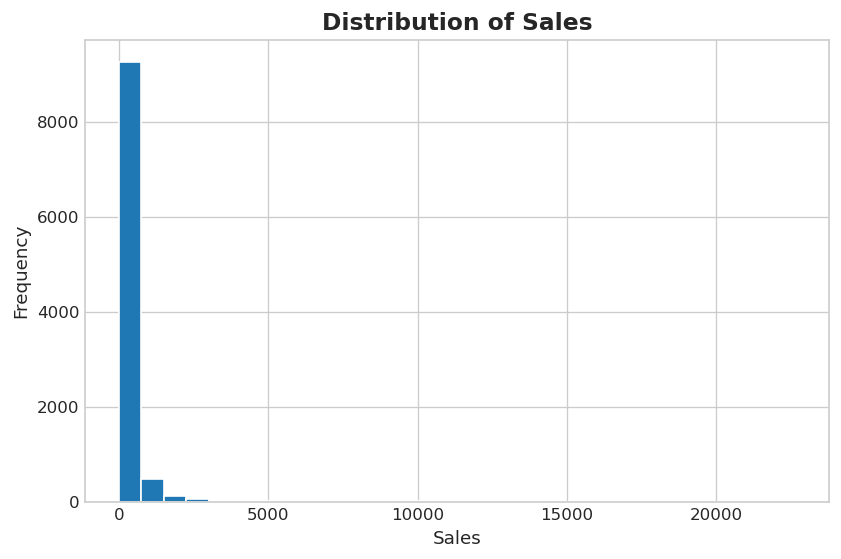

In [97]:
#Distribution of Sales

plt.figure(figsize=(8,5))
plt.hist(df['Sales'],bins=30, edgecolor= 'white')
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

The histogram shows that the majority of sales transactions are concentrated at lower sales values, while only a small number of transactions generate very high sales. This creates a heavily right-skewed distribution.

Most customer purchases fall within a small sales range, indicating that the business processes a large number of low-to-medium value orders rather than frequent high-ticket purchases.

The long tail on the right side of the distribution confirms the existence of high-value outlier transactions identified earlier in the boxplot analysis.

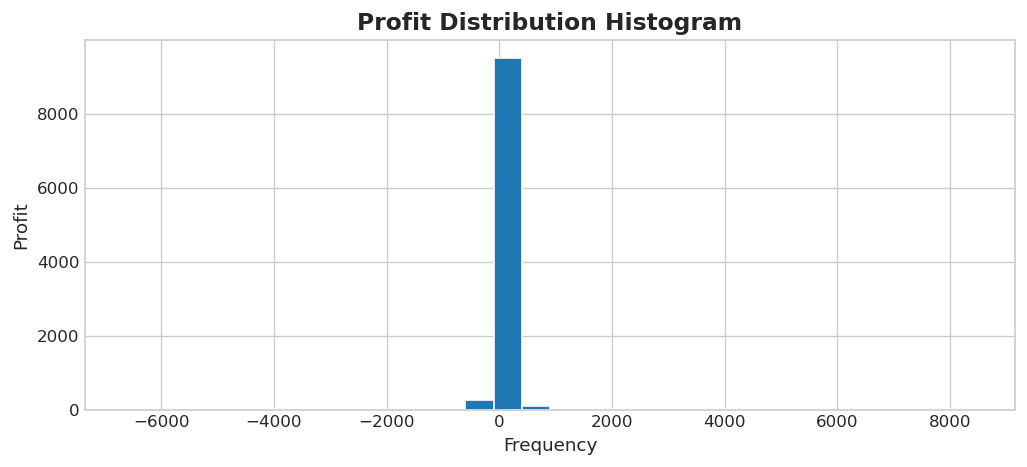

In [99]:
#Profit Distribution Histogram
plt.figure(figsize=(10,4))
plt.hist(df['Profit'],bins=30, edgecolor='white')
plt.title('Profit Distribution Histogram')
plt.xlabel('Frequency')
plt.ylabel('Profit')
plt.show()

The profit distribution histogram shows that most transactions generate small profits concentrated near the center of the distribution. However, the chart also reveals the presence of both high-profit and high-loss transactions.

The distribution includes:
positive profit concentration around moderate values
negative-profit transactions on the left side
extreme profit outliers on the right side

This indicates that while most orders remain profitable, some transactions result in significant losses.

The distribution appears slightly skewed, suggesting variability in profit margins across products and regions.

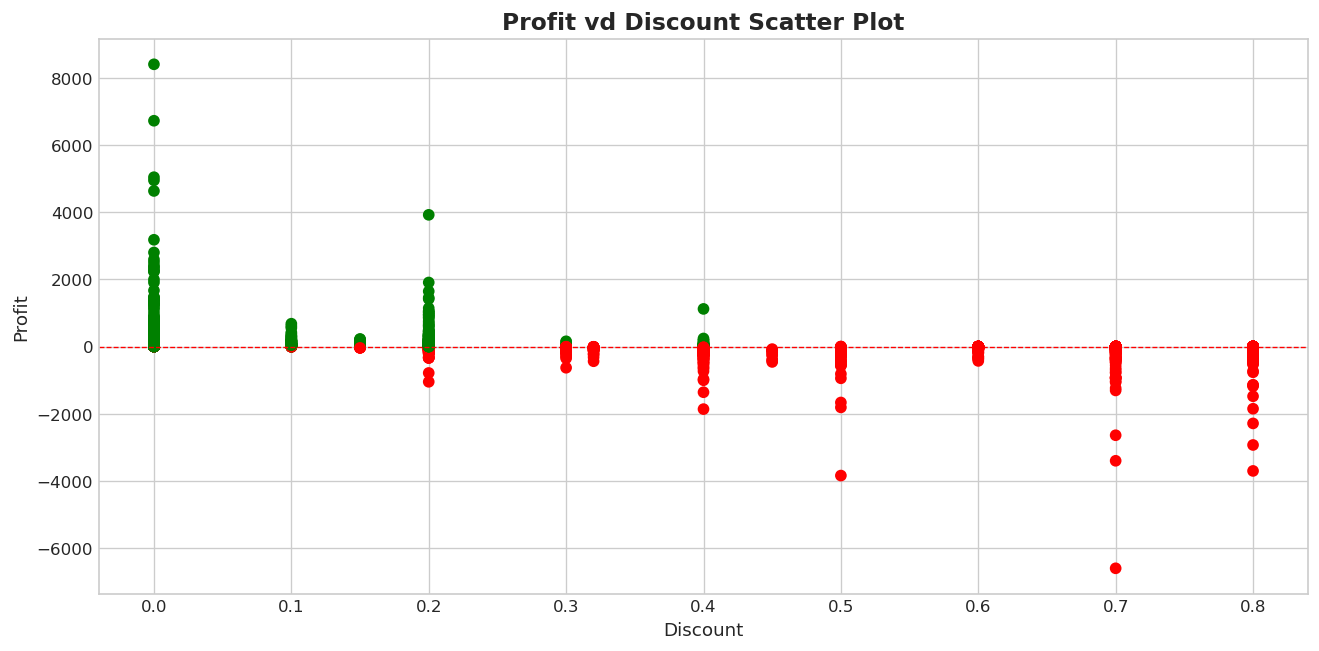

In [98]:
#Profit vs Discount Scatter Plot
colors = [
    'green' if p > 0 else 'red'
    for p in df['Profit']
]
plt.scatter(df['Discount'],df['Profit'], color= colors)
plt.axhline(0, color='red', linewidth=0.8, linestyle='--')
plt.title('Profit vd Discount Scatter Plot')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

The scatter plot clearly shows a strong relationship between discount levels and profitability. Orders with lower discounts (0%–20%) generally generate positive profits, represented by the green data points above the zero-profit line. However, as discounts increase beyond 30%–40%, a large number of transactions begin to generate negative profit, represented by red points below zero.
At very high discount levels such as:50%, 60%, 70%,80% most orders become loss-making transactions.
This indicates that aggressive discounting significantly reduces overall business profitability.
The analysis suggests:
excessive discounts directly impact profit margins
high-discount sales may increase revenue temporarily but reduce long-term profitability
certain products may be sold below sustainable margins

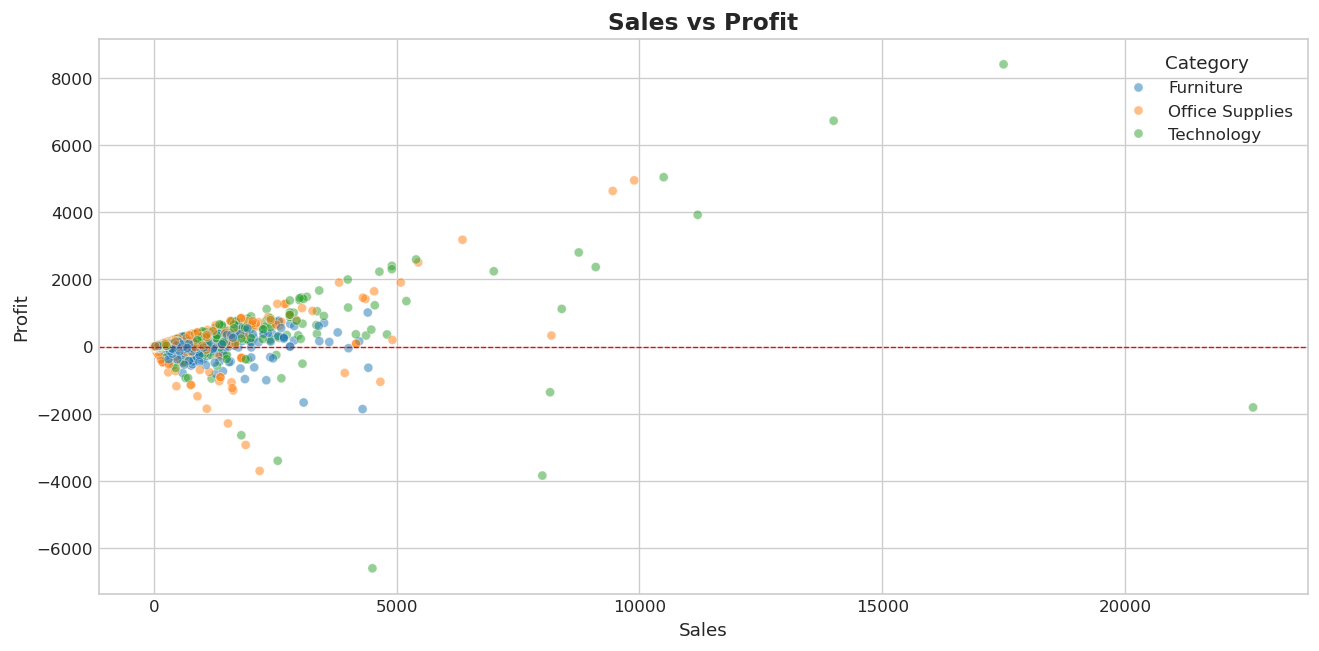

In [113]:
#Sales vs Profit Scatter Plot
sns.scatterplot(data = df,x='Sales',y='Profit', hue='Category',alpha =0.5 , s=30,edgecolor='white')
plt.axhline(0, color='red', linewidth=0.8, linestyle='--')    
plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')

plt.show()




The Sales vs Profit scatter plot demonstrates a generally positive relationship between sales and profit. As sales increase, profit also tends to increase for most transactions. However, several high-sales transactions still generate low or negative profit, indicating that high revenue does not always guarantee high profitability.

The chart also reveals:
most transactions are concentrated in lower sales ranges
only a few transactions contribute extremely high sales values
Technology products appear to generate stronger profit performance compared to some Furniture transactions

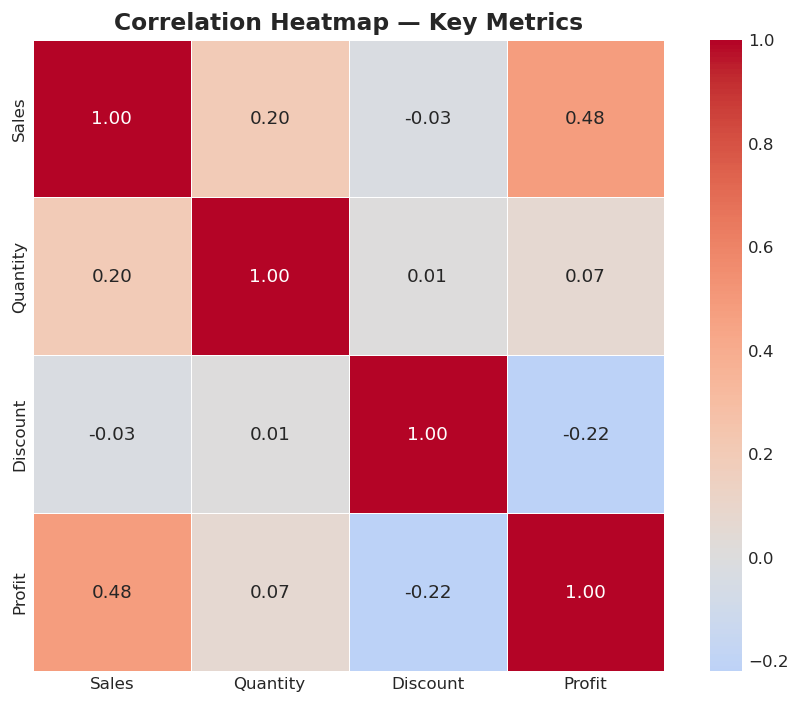

In [106]:
#Correlation Heatmap
corr_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Key Metrics')
plt.tight_layout()
plt.show()


The correlation heatmap measures relationships between:Sales Quantity Discount Profit



Sales and Profit → Positive Correlation (~0.48)
Higher sales generally lead to higher profit, indicating that increased revenue positively impacts business profitability.
However, the correlation is moderate rather than extremely strong, suggesting that other factors such as discounts and costs also affect profit.

Discount and Profit → Negative Correlation (~ -0.22)
Discount has a negative relationship with profit, confirming that larger discounts reduce profitability.
This supports findings from the discount scatter plot analysis.

Quantity and Profit → Weak Positive Correlation (~0.07)
Selling more quantity has only a small positive effect on profit.
This indicates that:
simply increasing units sold does not guarantee strong profitability
margin management remains important

Quantity and Discount → Near Zero Correlation(0.01)
This suggests discounting does not strongly increase product quantity sold in the dataset.
Heavy discounts may therefore not significantly improve demand.


The correlation analysis highlights that:
revenue growth alone is insufficient without profit optimization
discount strategies strongly influence business performance
balancing sales growth and profitability is essential

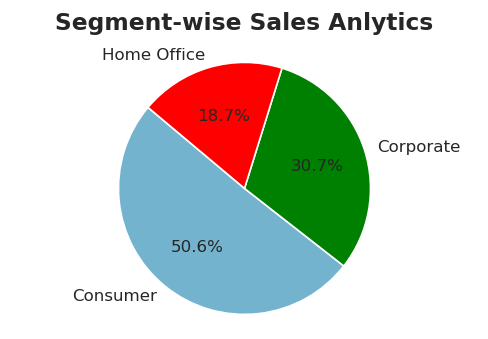

In [112]:
#Segment-wise Sales Pie Chart
Segment_Sales= df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
colors = ['#74B3CE', 'green', 'red']
plt.figure(figsize= (5,3))
wedges, texts, autotexts= plt.pie(Segment_Sales, labels = Segment_Sales.index,colors=colors,autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor':'white', 'linewidth':1},
    textprops={'fontsize':10}
)

plt.title('Segment-wise Sales Anlytics', fontsize=14, pad =12)
plt.axis('equal')
plt.show()

The segment-wise analysis reveals that the Consumer segment is the primary revenue driver for the ecommerce business, while Corporate customers also contribute significantly to sales performance. The Home Office segment currently contributes the least but presents future growth potential. These insights can help the business develop customer-specific marketing strategies, improve retention efforts, and optimize sales growth across different customer segments.